In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,

)

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import joblib
import mlflow
import mlflow.sklearn




In [3]:
df_clean = pd.read_csv('../data/processed/df_clean.csv')

In [4]:
df_clean['target'].value_counts()
# i dont need to handle class imbalance using SMOTE
# because i have a balanced distribution

target
HIGH_ACTIVITY     3383
LOWER_ACTIVITY    3137
CASH_ADVANCE      2430
Name: count, dtype: int64

In [5]:
#future story 5 : classification

#target selection

features = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

x = df_clean[features]

y = df_clean['target']

In [6]:
#data splitting

x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

y_train.value_counts()

# stratify=y : When we split the data into training and testing,
#  keep the same proportion of each target class in both sets.

#without it : 
# TRAIN
# HIGH_ACTIVITY              55%
# CASH_ADVANCE               35%
# LOWER_ACTIVITY             10%

# TEST
# HIGH_ACTIVITY              30%
# CASH_ADVANCE               10%
# LOWER_ACTIVITY             60%



target
HIGH_ACTIVITY     2706
LOWER_ACTIVITY    2510
CASH_ADVANCE      1944
Name: count, dtype: int64

Logistic Regression


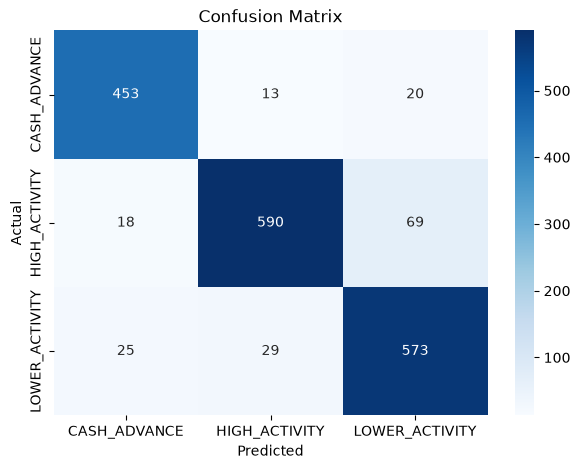

                precision    recall  f1-score   support

  CASH_ADVANCE       0.91      0.93      0.92       486
 HIGH_ACTIVITY       0.93      0.87      0.90       677
LOWER_ACTIVITY       0.87      0.91      0.89       627

      accuracy                           0.90      1790
     macro avg       0.90      0.91      0.90      1790
  weighted avg       0.90      0.90      0.90      1790

Random Forest


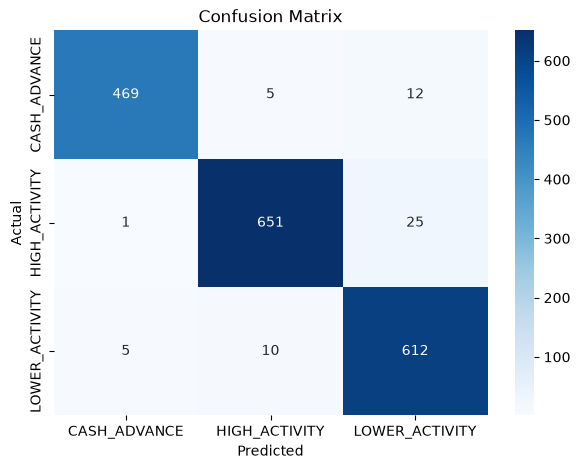

                precision    recall  f1-score   support

  CASH_ADVANCE       0.99      0.97      0.98       486
 HIGH_ACTIVITY       0.98      0.96      0.97       677
LOWER_ACTIVITY       0.94      0.98      0.96       627

      accuracy                           0.97      1790
     macro avg       0.97      0.97      0.97      1790
  weighted avg       0.97      0.97      0.97      1790



c:\Users\Youcode\Desktop\DEV Ai\segmentation_clients\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC


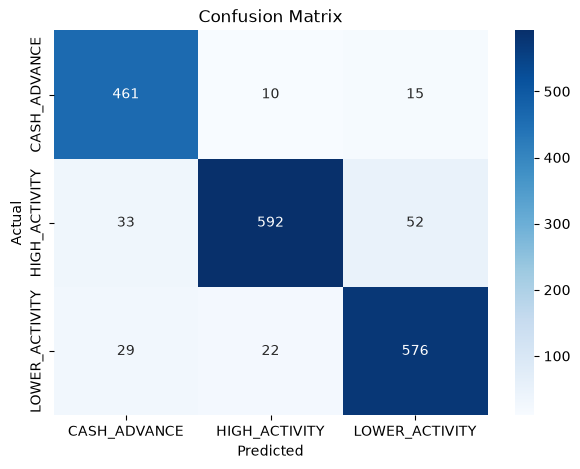

                precision    recall  f1-score   support

  CASH_ADVANCE       0.88      0.95      0.91       486
 HIGH_ACTIVITY       0.95      0.87      0.91       677
LOWER_ACTIVITY       0.90      0.92      0.91       627

      accuracy                           0.91      1790
     macro avg       0.91      0.91      0.91      1790
  weighted avg       0.91      0.91      0.91      1790



In [7]:
#creating pipeline with classifiers object

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42 ),
    'Random Forest' : RandomForestClassifier(n_estimators=100 , random_state=42 ),
    'SVC' : SVC( kernel='rbf', probability=True )
}

for name , classifier in classifiers.items():

    pipeline = Pipeline([
        ('scaler' , StandardScaler()),
        ('classifier' , classifier)
    ])

    #train
    pipeline.fit(x_train , y_train) #fit handles the lable encoder inside it , so it transform the classes into indexes

    #predict
    y_pred = pipeline.predict(x_test)

    # predict probas with our custom seuil
    # proba = pipeline.predict_proba(x_test)


    # seuil = 0.60

    # max_proba = proba.max(axis=1)
    # max_index = proba.argmax(axis=1)  # we get the max proba and its index

    # y_pred = np.where(  
    #     max_proba >= seuil,  # if this proba is > seuil we get its class else we say uncertain
    #     pipeline.classes_[max_index],
    #     'uncertain'

    # )
    print(name)
    # matrice de confusion
    labels = sorted(set(y_test.unique()) | set(y_pred))
    cm = confusion_matrix(y_test , y_pred , labels=labels)

    plt.figure(figsize=(7,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()



    
    print(classification_report(y_test, y_pred))

In [8]:
# now the gridsearch and cross validation using gridsreachCV 
# RandomizedSearchCV is like gridsearch but it randomize the params

# i created a dictionnary of params for each model

param_grids = {

    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga']
    },

    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 5, 10],
        'classifier__max_features': ['sqrt', 'log2']
    },

    'SVC': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['rbf', 'linear'],
        'classifier__gamma': ['scale', 'auto']
    }
}

In [ ]:
# creating the experiment for mlflow

mlflow.set_experiment("classification_clients")

best_model = None
best_score = 0
result = []

for name, classifier in classifiers.items():
    with mlflow.start_run(run_name=name):
        print("\n")
        print(name)

        # Pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', classifier)
        ])

        # GridSearchCV
        grid = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grids[name],
            cv=3,
            scoring='f1_weighted',
            n_jobs=-1,
        )

        # Train
        grid.fit(x_train, y_train)

        

        
        best_params = grid.best_params_

        # Predict with optimized model
        y_pred = grid.best_estimator_.predict(x_test)

        # calculate metrics
        f1score = f1_score(y_test, y_pred , average='weighted')
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test, y_pred, average='weighted', zero_division=0
        )
        recall = recall_score(
            y_test, y_pred, average='weighted', zero_division=0
        )
        


        # getting the best model for serialisation
        if grid.best_score_ > best_score :
                    best_score = grid.best_score_
                    best_model = grid.best_estimator_

        result.append(
                {
                'model' : name,
                'best params' : best_params,
                'f1_score' : f"{f1score:.3f}",
                'accuracy' : f"{accuracy:.3f}"
                }
        )

        #logging
        mlflow.log_param("model_name", name)
        mlflow.log_params(best_params)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision_weighted", precision)
        mlflow.log_metric("recall_weighted", recall)
        mlflow.log_metric("f1_weighted", f1score)

        #Log the best cross-validation score
        mlflow.log_metric("cv_f1_weighted", grid.best_score_)

        #save the complete pipeline
        mlflow.sklearn.log_model(
            grid.best_estimator_,
            name="pipeline",
            skops_trusted_types=["sklearn.tree._tree.Tree"]
        )


        # Create the confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"Confusion Matrix - {name}")
        plt.tight_layout()

        # save the image
        cm_path = f"confusion_matrix_{name.replace(' ', '_')}.png"
        plt.savefig(cm_path)
        plt.close()

        # Log the image to this MLflow run
        mlflow.log_artifact(
            cm_path,
            artifact_path="evaluation"
        )
    

print(best_model)
print(best_score)





Logistic Regression


c:\Users\Youcode\Desktop\DEV Ai\segmentation_clients\.venv\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Youcode\Desktop\DEV Ai\segmentation_clients\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
2026/10/10 22:21:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.




Random Forest


2026/10/10 22:21:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.




SVC


c:\Users\Youcode\Desktop\DEV Ai\segmentation_clients\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
2026/10/10 22:21:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_features='log2', random_state=42))])
0.9664853817220291
MLflow version: 3.17.0
Tracking URI: sqlite:///C:/Users/Youcode/Desktop/DEV%20Ai/segmentation_clients/notebooks/mlflow.db
Current experiment: <Experiment: artifact_location='file:c:/Users/Youcode/Desktop/DEV Ai/segmentation_clients/notebooks/mlruns/1', creation_time=1791670284945, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791670284945, lifecycle_stage='active', name='classification_clients', tags={}, trace_location=None, workspace='default'>


In [10]:
results_df = pd.DataFrame(result)
results_df

,model,best params,f1_score,accuracy
0,Logistic Regression,"{'classifier__solver': 'saga', 'classifier__C'...",0.904,0.904
1,Random Forest,"{'classifier__n_estimators': 100, 'classifier_...",0.968,0.968
2,SVC,"{'classifier__kernel': 'rbf', 'classifier__gam...",0.934,0.934


<Axes: xlabel='model', ylabel='f1_score'>

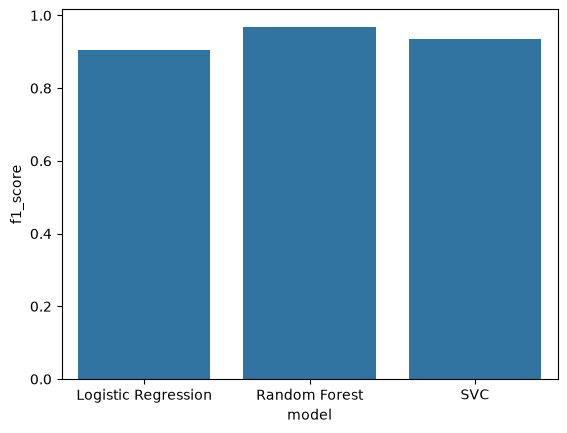

In [11]:
results_df['f1_score'] = pd.to_numeric(
    results_df['f1_score'], errors='coerce'
)


sns.barplot(data=results_df, x='model', y='f1_score')


In [12]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['CASH_ADVANCE','HIGH_ACTIVITY','LOWER_ACTIVITY']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [13]:

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']